# ***Introduction to Artificial Neural Networks***

***Machine learning model inspired by the networks of the biological neuron found in our brain, Artificial Neural Networks (ANN)***

***`ANN are at very core of deep learning`***

***They are versatile, powerful, and scalable, making them ideal to tackle large and highly complex machine learning tasks***

## ***From Biological to Artifciial Neurons***

### ***Biological Neurons***

### ***Logical Computations with Neurons***

***very simple model of the biological neuron, artificial neuron. it has one or more binary (on/off) inputs and one binary output.The artificial neuron activates its output when more than a certain number of its inputs are active.***

### ***The Perceptron***

***It is based on a slightly different artificial neuroncalled a threshold logic unit (TLU), or sometimes a linear threshold unit (LTU). The inputs and output are numbers (instead of binary on/off values), and each input connection is associated with a weight***

***TLU computes a linear function of it;s input $$z = w_1 x_1 + w_2 x_2 \dots + w_n x_n + b = w^T + b$$ Then apply step func to the result $$h_w(x) = step(x)$$***

***Just like in logistic regression, the model parameters are the input weights w and the bias term b***

***Most common step func is Heaviside step func, sometimes sign func***
$$heaviside(z)=
\begin{cases}
0 & \text{if } z < 0\\
1 & \text{if } z \ge 0
\end{cases}
$$
$$
sgn(z)=
\begin{cases}
-1 & \text{if } z < 0\\
0 & \text{if } z = 0\\
+1 & \text{if } z > 0
\end{cases}
$$

***A single TLU can be used for simple linear binary classification, for example, use a single TLU to classify iris flowers based on petal length and width. Training such a TLU would require finding the right values for `w1`, `w2`, and `b`***

***A perceptron is composed of one or more TLUs organized in a single layer, where every TLU is connected to every input. Such a layer is called a fully connected layer, or a dense layer. The inputs constitute the input layer. And since the layer of TLUs produces the final outputs, it is called the output layer.***

***To compute the outputs of a layer of artificial neurons for several instances at once use*** $$\hat Y = \varphi (XW + b)$$
- *$\hat y$ the output matrix. It has one row per instance and one column per neuron*
- *$X$ is the input matrix. It has one row per instance and one column per input feature*
- *Weight $W$ contains all the connection weights. It has one row per input feature and one column per neuron*
- *The bias vector b contains all the bias terms: one per neuron.*
- *$\phi$ is activation func when the artificial neuron is TLUs it's a step func*


***`The perceptron training algorithm proposed by Rosenblatt was largely inspired by Hebb’s rule.` when a biological neuron triggers another neuron often, the connection between these two neurons grows stronger `“Cells that fire together, wire together”` that is the connection weight between two neurons tends to increase when they fire simultaneously***

***the perceptron is fed one training instance at a time, and for each instance it makes its predictions. For every output neuron that produced a wrong prediction, it reinforces the connection weights from the inputs that would have contributed to the correct prediction. The rule is shown in $$w_{i,j}^{(\text {next step})} = w_{i,j} + \eta (y_j - \hat y_j) x_i$$***
- *$w_{i,j}$ is connecting weight b/w $i^{th}$ input & $j^{th}$ neuron*
- *$x_i$ $i^{th}$ input value of the current training instance*
- *$\hat y_j$ is the output of the $j^{th}$ output neuron for the current training instances*
- *$y_j$ is the target o/p of the $j^{th}$ o/p neuron for the current training instance*
- *$\eta$ is the learning rate*

***The `decision boundary (line)` of each output neuron is linear, so perceptrons are incapable of learning complex patterns (just like logistic regression classifiers). If the training instances are linearly separable this algorithm will converge to a solution called `the perceptron convergence theorem`***

In [1]:
import numpy as np 
from sklearn.datasets import load_iris 
from sklearn.linear_model import Perceptron

from matplotlib import pyplot as plt

In [9]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target==0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [2, 1], [3, 1]]
y_pred = per_clf.predict(X_new)

y_pred

array([ True, False, False])

***The perceptron learning algorithm strongly resembles stochastic gradient descent***

***`Perceptron class is equivalent to using an SGDClassifier with the following hyperparameters: loss="perceptron", learning_rate="constant", eta0=1 (the learning rate), and penalty=None (no regularization)`***

***There are many weakness of perceptron like the XOR classification***

***some of the limitations of perceptrons can be eliminated by stacking multiple perceptrons. The resulting ANN is called a multilayer perceptron (MLP)***

In [10]:
# shows how to build and train a Perceptron

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="perceptron", penalty=None,
                        learning_rate="constant", eta0=1, random_state=42)
sgd_clf.fit(X, y)
assert (sgd_clf.coef_ == per_clf.coef_).all()
assert (sgd_clf.intercept_ == per_clf.intercept_).all()

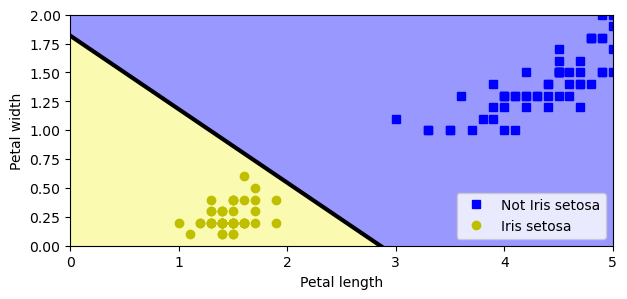

In [11]:
#plots the decision boundary of a Perceptron on the iris dataset

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-",
         linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
plt.show()

### ***The Multilayer Perceptron and Backpropagation***

***An MLP is composed of one input layer, one or more layers of artificial neurons (originally TLUs) called hidden layers, and one final layer of artificial neurons called the output layer. The layers close to the input layer are usually called the lower layers, and the ones close to the outputs are usually called the upper layer***

***When an ANN contains a deep stack of hidden layers, 11 it is called a deep neural network (DNN)***

***Rearchers struggled to find a way to train MLPs, using `gradient descent` to train neural networks this requires computing the `gradients` of the model’s error with regard to the model parameters; it wasn’t clear at the time how to do this efficiently with such a complex model containing so many parameters***

***Algo reverse-mode automatic difefrentiation (or reverse-mode autodif),In just two passes through the network (one forward, one backward), it is able to compute the gradients of the neural network’s error with regard to every single model parameter. These gradients can then be used to perform a gradient descent step. If you repeat this process of computing the gradients automatically and taking a gradient descent step, the neural network’s error will gradually drop until it eventually reaches a minimum. This combination of reverse-mode autodiff and gradient descent is now called backpropagation***

***How backpropagation works~***
- *One mini batch at a time, if it has 32 instances & 100 feature then the batch will be represented as a matrix with 32 row & 100 cols. Each pass through the training set is called an `epoch`*
- *For each mini batch algo comptue o/p of all the neurons in the first hidden layer using $\hat y = \varphi (XW + b)$. If the layer has 50 neurons then its output is a matrix with one row per sample in the mini-batch (e.g., 32), and 50 columns, then the matrix is passed to next layer ... until we get o/p in last layer. this is forward pass `(all intermediate results are preserved since they are needed for the backward pass)`*
- *Next, the algorithm measures the network’s output error*
- *Then it computes how much each output layer parameter contributed to the error, this is done applying `chain rule`. The result is one gradient per parameter*
- *The algorithm then measures how much of these error contributions came from each connection in the layer below, again using the chain rule, working backward until it reaches the input layer. This reverse pass efficiently measures the error gradient across all the connection weights and biases in the network by `propagating the error gradient backward through the network`*
- *Finally, the algorithm performs a gradient descent step to tweak all the connection weights and bias terms in the network, using the error gradients it just computed*

***In order for backprop to work properly,replaced the step function with the logistic function, $\sigma(z) = 1 / (1 + exp(–z))$, also called the sigmoid function. As the `step func` only contain flat surface so there was not gradient, but `sigmoid func` has well-defined nonzero derivative everywhere***

***Some other activation function~***
- *The hyperbolic tangent function: tanh(z) = 2σ(2z) – 1 : Sshaped, continuous, and differentiable, but its output value ranges from –1 to 1*
- *The rectified linear unit function: ReLU(z) = max(0, z) : continuous but unfortunately not difefrentiable at z = 0 (the slope changes abruptly, which can make gradient descent bounce around), and its derivative is 0 for z < 0. In practice, however, it works very well and has the advantage of being fast to compute, default for many architecture except transformer model*

***Why do we need activation functions in the first place?***

***a large enough DNN with nonlinear activations can theoretically approximate any continuous function***

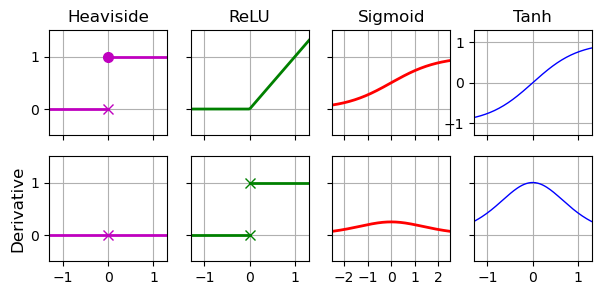

In [3]:
from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps)) / (2 * eps)

max_z = 2.5
z = np.linspace(-max_z, max_z, 200)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(7, 3))

axes[0, 0].plot([-max_z, 0], [0, 0], "m-", linewidth=2)
axes[0, 0].plot(0, 0, "mx", markersize=7)
axes[0, 0].plot(0, 1, "mo", markersize=7)
axes[0, 0].plot([0, max_z], [1, 1], "m-", linewidth=2)
axes[0, 0].set_title("Heaviside", fontsize=12)
axes[1, 0].plot(z, derivative(np.sign, z), "m-", linewidth=2)
axes[1, 0].plot(0, 0, "mx", markersize=7)
axes[1, 0].set_ylabel("Derivative", fontsize=12)
axes[0, 1].plot(z, relu(z), "g-", linewidth=2)
axes[0, 1].set_title("ReLU", fontsize=12)
axes[1, 1].plot([-max_z, 0], [0, 0], "g-", linewidth=2)
axes[1, 1].plot([0, max_z], [1, 1], "g-", linewidth=2)
axes[1, 1].plot(0, 0, "gx", markersize=7)
axes[1, 1].plot(0, 1, "gx", markersize=7)

axes[0, 2].plot(z, sigmoid(z), "r-", linewidth=2)
axes[0, 2].set_title("Sigmoid", fontsize=12)
axes[1, 2].plot(z, derivative(sigmoid, z), "r-", linewidth=2)

axes[0, 3].plot(z, np.tanh(z), "b-", linewidth=1)
axes[0, 3].set_title("Tanh", fontsize=12)
axes[1, 3].plot(z, derivative(np.tanh, z), "b-", linewidth=1)

for row in range(2):
    for col in range(4):
        axes[row, col].grid(True)
        if row == 0:
            axes[row, col].set_xticklabels([])
        if col == 2:
            axes[row, col].set_xlim(-max_z, max_z)
            axes[row, col].set_xticks([-2, -1, 0, 1, 2])
        else:
            axes[row, col].set_xlim(-1.3, 1.3)
            axes[row, col].set_xticks([-1, 0, 1])
        if col != 0 and ((row, col) != (0, 3)):
            axes[row, col].set_yticklabels([])
        if (row, col) == (0, 3):
            axes[row, col].set_ylim(-1.3, 1.3)
            axes[row, col].set_yticks([-1, 0, 1])
        else:
            axes[row, col].set_ylim(-0.5, 1.5)
            axes[row, col].set_yticks([0, 1])

plt.show()

## ***Building and Training MLPs with Scikit-Learn***

### ***Regression MLPs***

***Use `MLPRegressor` class. so let’s build an MLP with three hidden layers composed of 50 neurons each, and train it on the California housing dataset***

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [5]:
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, random_state=42)

***The first hidden layer’s i/p size and the o/p layer’s output size will adjust automatically to the dimensionality of the inputs and targets, when training starts. The model uses the ReLU activation func in all hidden layers, and no activation func at all on the output layer. We also set `verbose=True` to get details on the model’s progress during training***

***As there are many parameter in NNets, they may overfit to solve this use `early_stopping=True`***

In [6]:
mlp_reg =  MLPRegressor(hidden_layer_sizes=[50, 50, 50],early_stopping=True, verbose=True, random_state=42)

***class automatically sets aside 10% of the training data and uses it to evaluate the model at each epoch `[validation_fraction]`, If the validation score stops improving for 10 epochs, training automatically stops `[n_iter_no_change]`***

***Now create a pipeline to standardize the i/p features before sending to `MLPRegressor` as gradient descet doesn't converge well when features have different scale***

***MLPRegressor use the varient of Gradient descent called Adam to minimize MSE, it also use a bit $l_2$ regularization***

In [7]:
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)

Iteration 1, loss = 0.85190332
Validation score: 0.534299
Iteration 2, loss = 0.28288639
Validation score: 0.651094
Iteration 3, loss = 0.22884372
Validation score: 0.699782
Iteration 4, loss = 0.20746145
Validation score: 0.720468
Iteration 5, loss = 0.19649383
Validation score: 0.724839
Iteration 6, loss = 0.18928708
Validation score: 0.740084
Iteration 7, loss = 0.18132029
Validation score: 0.747406
Iteration 8, loss = 0.17556450
Validation score: 0.753945
Iteration 9, loss = 0.17190651
Validation score: 0.760500
Iteration 10, loss = 0.16687650
Validation score: 0.759213
Iteration 11, loss = 0.16329479
Validation score: 0.761907
Iteration 12, loss = 0.16054473
Validation score: 0.768950
Iteration 13, loss = 0.15690181
Validation score: 0.762699
Iteration 14, loss = 0.15630644
Validation score: 0.766003
Iteration 15, loss = 0.15712517
Validation score: 0.778464
Iteration 16, loss = 0.15155981
Validation score: 0.774237
Iteration 17, loss = 0.14957641
Validation score: 0.778361
Iterat

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True,
                              hidden_layer_sizes=[50, 50, 50], random_state=42,
                              verbose=True))])

***So the MLP require 45 epochs & the loss func went down & validation score went up in each epoch***

***MLPRegressor uses the R2 score by default for evaluation that’s what the score() method returns, here it's near 80% which is fairly good for this task***

In [12]:
mlp_reg.best_validation_score_

0.791536125425778

In [13]:
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.5327699946812925

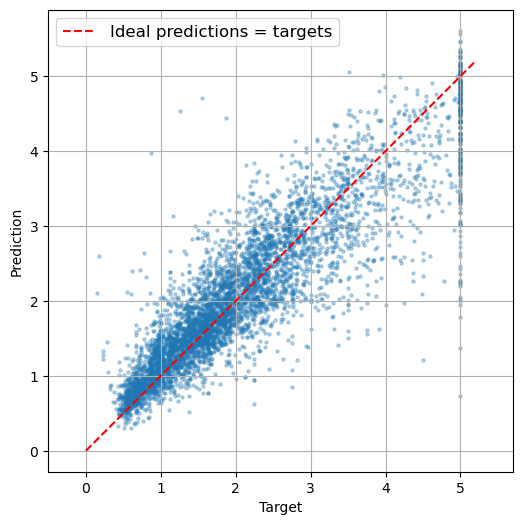

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.3)
plt.plot([0, 5.2], [0, 5.2], color='red', linestyle='--',
         label="Ideal predictions = targets")
plt.axis("equal")
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.legend(fontsize=12)
plt.grid()

plt.show()

***MLP does not use any activation function for the output layer, so it’s free to output any value it wants. If always want a positive o/p then should use `RELU` a. func on o/p layer or `softplus` `(softer version of RELU)` softplus(z) = log(1 + exp(z)) want to guarantee that the predictions always fall within a given range of values, then you should use the sigmoid function or the hyperbolic tangent, and scale the targets to the appropriate range: 0 to 1 for `sigmoid` and –1 to 1 for `tanh`***

***For loss MSE is perfect for rregression but if there are many outlier use MAbsoluteE or Huber loss (comb of both)***

***Table 9-1. Typical Regression MLP Architecture***

| Hyperparameter | Typical Value |
|---------------|---------------|
| **# hidden layers** | Depends on the problem, but typically **1 to 5** |
| **# neurons per hidden layer** | Depends on the problem, but typically **10 to 100** |
| **# output neurons** | **1 per target dimension** |
| **Hidden activation** | **ReLU** |
| **Output activation** | None, or **ReLU/softplus** (if positive outputs) or **sigmoid/tanh** (if bounded outputs) |
| **Loss function** | **MSE**, or **Huber** if outliers are present |

### ***Classification MLPs***

***For a binary classification need 1 o/p neuron, MLP can do multiple binary classification***

***If each instance belong only to a single class, we need 1 neuron per class & softmax func for whole o/p layer, this ensure that all the estimated probabilities are between 0 and 1, and that they add up to 1, since the classes are exclusive***

***Since predicting probability dist cross-entropy loss is a good choice***

***Table 9-2. Typical Classification MLP Architecture***

| Hyperparameter | Binary Classification | Multilabel Binary Classification | Multiclass Classification |
|---------------|----------------------|----------------------------------|--------------------------|
| **# hidden layers** | Typically **1 to 5** layers, depending on the problem | Typically **1 to 5** layers, depending on the problem | Typically **1 to 5** layers, depending on the problem |
| **# output neurons** | **1** | **1 per binary label** | **1 per class** |
| **Output layer activation** | **Sigmoid** | **Sigmoid** | **Softmax** |
| **Loss function** | **Cross-entropy** | **Cross-entropy** | **Cross-entropy** |

***`MLPClassification` its output layer uses the softmax activation function, and it minimizes the cross-entropy loss rather than the MSE, the score() method returns the model’s accuracy rather than the R2 score***

***Fashion MNIST 70,000 grayscale image with 28x28 pixels each with 10 class***

- ***Simple linear model reaches 92% accuracy on MNIST but only 83% on fashion MNIST***

In [15]:
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name='Fashion-MNIST', as_frame=False)
targets = fashion_mnist.target.astype(int)

In [16]:
X_train, y_train = fashion_mnist.data[:60000], targets[:60000]
X_test, y_test = fashion_mnist.data[60000:], targets[60000:]

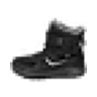

In [17]:
X_sample = X_train[0].reshape(28, 28)
plt.figure(figsize=(1, 1)) # reduce image size
plt.imshow(X_sample, cmap="binary") 
plt.axis("off") # remove the axis
plt.show()

In [18]:
# creating list of class names for the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress",  "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"] 

In [19]:
class_names[y_train[0]]

'Ankle boot'

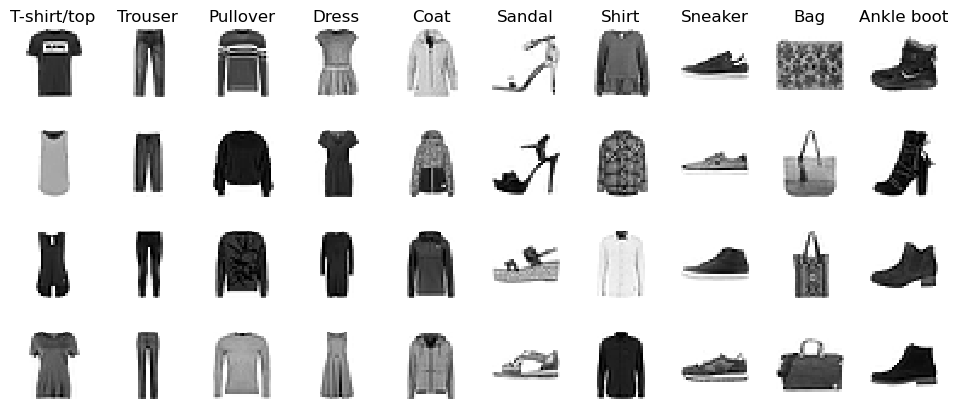

In [20]:
#this cell generates Figure 9–10
n_rows = 4
plt.figure(figsize=(12, n_rows * 1.2))
for row in range(n_rows):
    for class_index in range(10):
        X_img = X_train[y_train==class_index][row].reshape(28, 28)
        y_img = y_train[y_train==class_index][row]
        plt.subplot(n_rows, 10, 10 * row + class_index + 1)
        plt.imshow(X_img, cmap="binary", interpolation="nearest")
        plt.axis('off')
        if row == 0:
            plt.title(class_names[y_img])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

In [21]:
# classifier MLP
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler

mlp_clf = MLPClassifier(hidden_layer_sizes=[300,100], verbose=True, early_stopping=True,random_state=42)  # 2 hidden layer with 300 & 100 neurons respectively

pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)
accuracy

Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

0.8929

In [22]:
mlp_clf.best_validation_score_

0.9023333333333333

***use MinMaxScaler as We need it to shrink the pixel intensities down to the 0–1 range rather than 0–255: having features in this range usually works better with the default hyperparameters used by MLPClassifier,such as its default learning rate and weight initialization scale***

***some pixels don’t vary much across images; for example, the pixels around the edges are almost always white. If we used the StandardScaler, these pixels would get scaled up to have the same variance as every other pixel: as a result, we would give more importance to these pixels than they probably deserve***

***There are som much parameter it sometimes lead to overfitting when we don\'t have much data, in case we ues regularization technique like `early stopping` & `$l_2$ regularization` to prevent overfitting.***

In [23]:
X_new = X_test[:15]
mlp_clf.predict(X_new)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4])

In [24]:
# only the prediction in 12th index is wrong, the rest are correct
# confident in prediction 
y_prob = mlp_clf.predict_proba(X_new)
y_prob[12]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [26]:
y_proba = mlp_clf.predict_proba(X_test)
(y_proba.max(axis=1) < 0.99).sum()

20

***So the model is 100% confident on a wrong prediction, in 10,000 test image only in 20 image confident is less than 99.9%, so neural nets are overconfident especially when trained for too long***

***Can finetune hyperparameter for better performance***

## ***Hyperparameter Tuning Guidelines***

***Network architecture, //
number of layers, //
number of neurons and the type of activation function to use in each layer, //
weight initialization logic, // 
type of optimizer to use, //
learning rate, //
batch size, and more***

### ***Number of Hidden Layers***

***For many pblm can use 1 hidden layer, but DNN have much higher parameter efficiency than shallow ones, they can model complex func using exponentially fewer neuron than shallow nets reach same performance with same training data as layered structure enables them to reuse and compose features across multiple levels, it also improves their ability to generalize to new datasets***

***Transfer learning ...***

***Increase the number of hidden layers until start overfitting***

### ***Number of Neuron per Hidden Layer***

***No of neuron on i/p & o/p layer is tetermined by the type of i/p 7 O/P***

***Mostly like a pyramide fewer & fewer in high level feature, but using same number gives the same result***

***Increase the number of neuron until starts to overfit***

***Or can use with more neuron than required & use `early stopping ` & other regularization method***

***Stretch pants method ...***

### ***Learning Rate***

***In general optimal lr is half of max lr***

***Train a model for a few iterations, starting with a very low lr & gradually increase it upto a very large value (by mult lr by a constant factor at eac iteration). If plot the loss as a func of lr can see a drop first then lr will be very large & the loss will increase, optimal lr is lower than the point where the loss starts to climb***

***Now reinitialize my model & train it normally using good lr***

### ***Batch Size***

***Largest batch size that can fit in VRAM (eg: GPU memory), sometimes can cause training instability for small models***

***Using small batches (from 2 to 32) was preferable because small batches led to better models in less training time***

***strategy is to use a large batch size, possibly with learning rate warmup, and if training is unstable or the final performance is disappointing, then try using a smaller batch size instead***

### ***Other Hyperparameters***

***Optimizer : Choosing a better optimizer than plain old mini-batch gradient descent (and tuning its hyperparameters) can help speed up training and sometimes reach better performance***

***Activation Function : in general RELU is good in some case replace RELU with some other func***